In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
df.shape

(1338, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


# Проверка на наличие пропусков

In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(1)

In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
df['charges'].value_counts()

charges
1639.56310     2
6203.90175     1
12981.34570    1
28101.33305    1
28923.13692    1
              ..
1163.46270     1
19496.71917    1
7201.70085     1
5425.02335     1
16115.30450    1
Name: count, Length: 1337, dtype: int64

# Одномерный анализ

In [20]:
# Определяем типы колонок
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# ВАЖНО: в датасете children — это int, но по сути категориальный
# Вручную переносим его в категориальные
if 'children' in num_cols:
    num_cols.remove('children')
    cat_cols.append('children')

print(f"Числовые: {num_cols}")
print(f"Категориальные: {cat_cols}")

Числовые: ['age', 'bmi', 'charges']
Категориальные: ['sex', 'smoker', 'region', 'children']


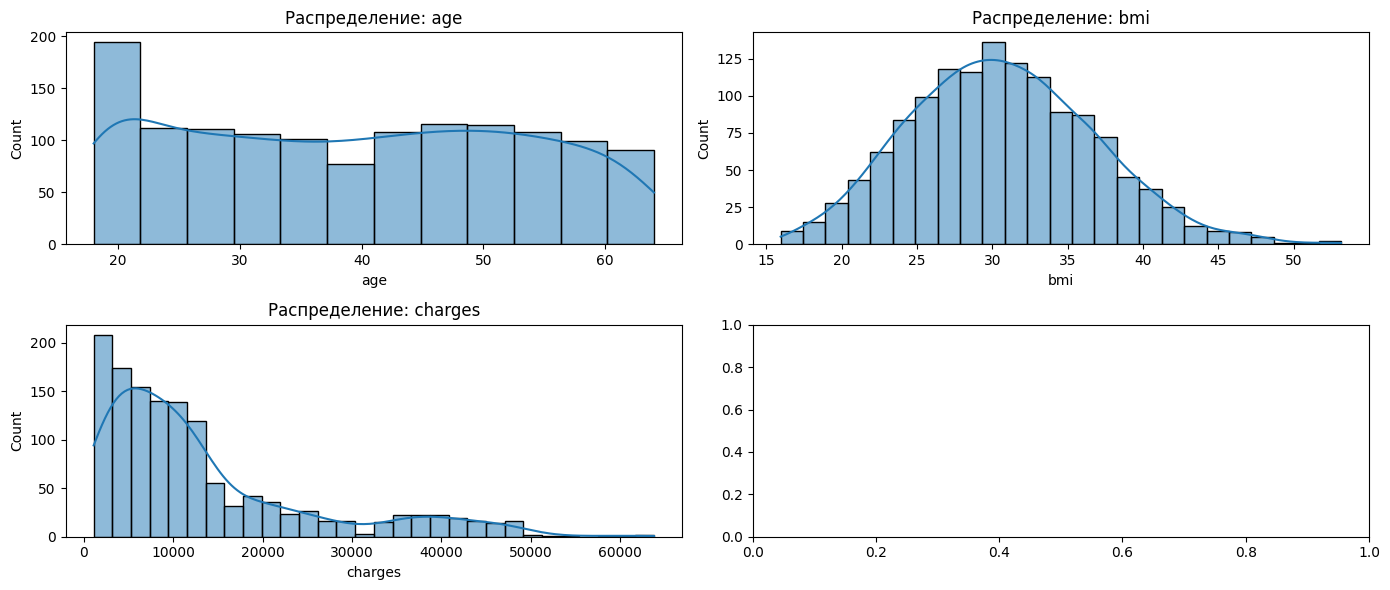

In [21]:
# Распределения числовых признаков
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Распределение: {col}')

plt.tight_layout()
plt.show()

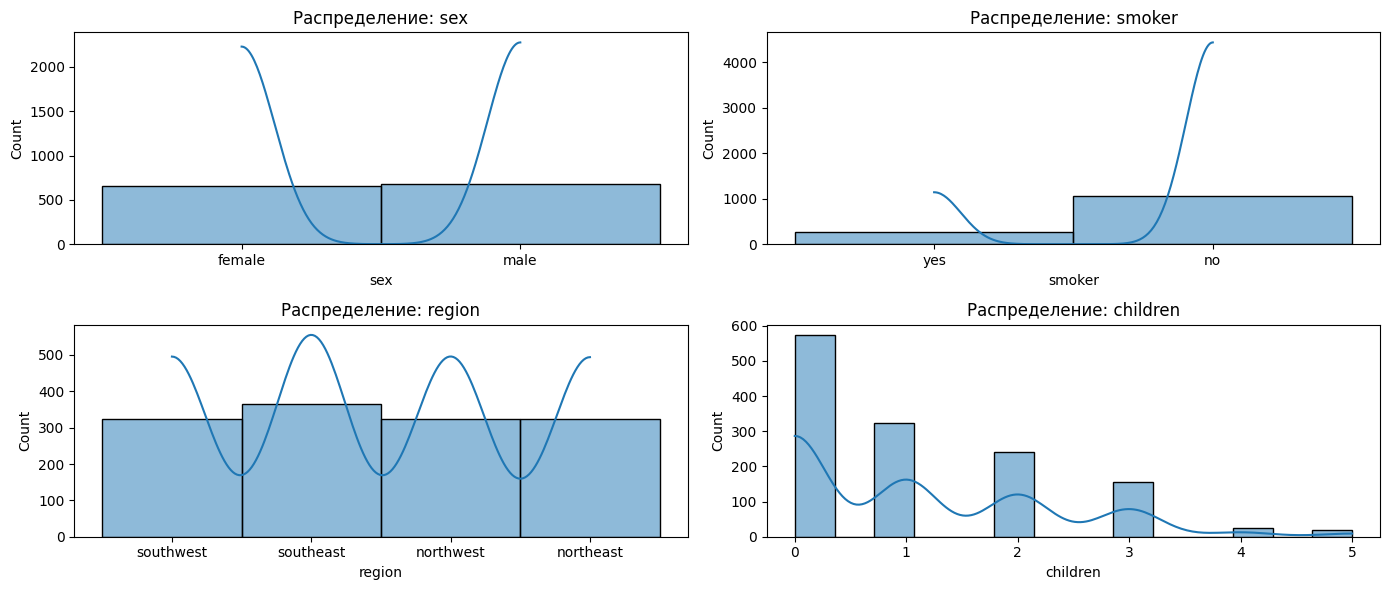

In [22]:
# Распределения категориальных признаков
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Распределение: {col}')

plt.tight_layout()
plt.show()

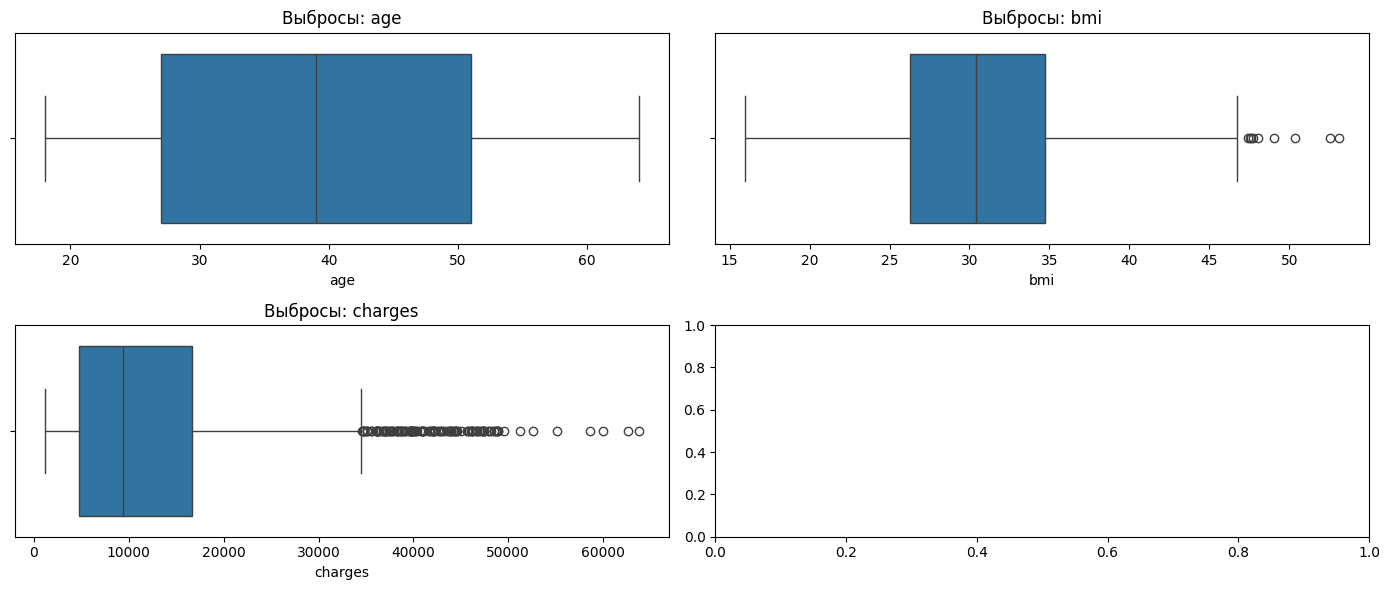

In [23]:
# Выбросы числовых признаков
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Выбросы: {col}')

plt.tight_layout()
plt.show()

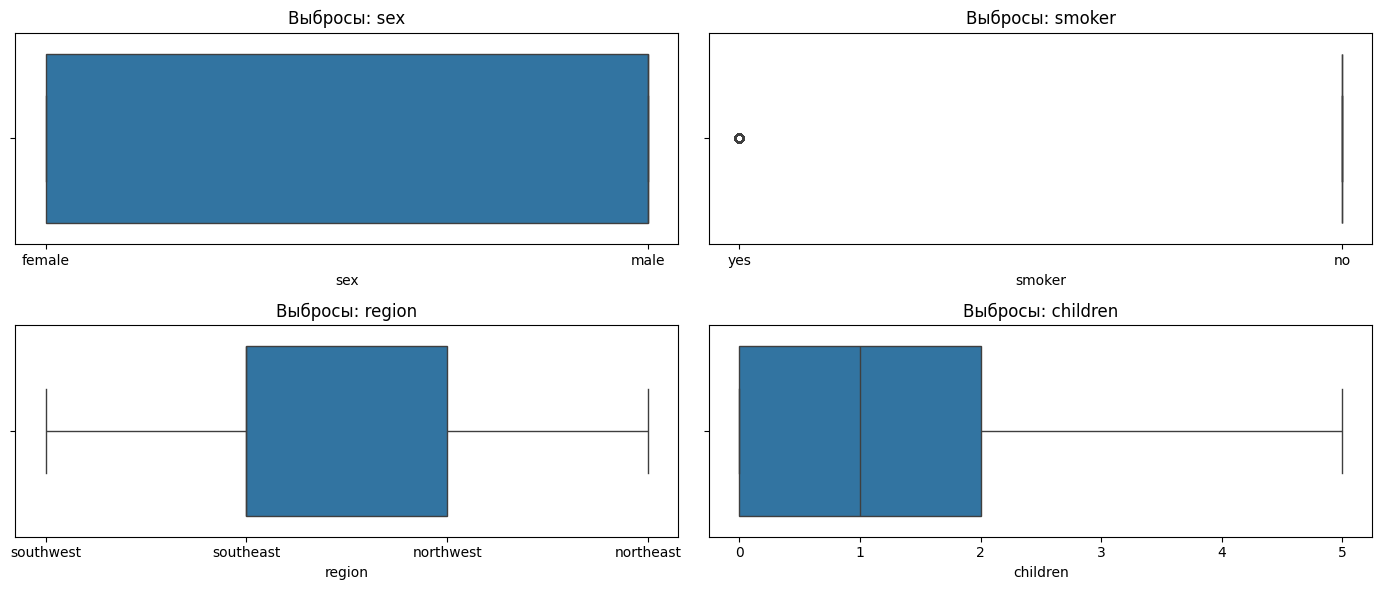

In [24]:
# Выбросы категориальных признаков
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Выбросы: {col}')

plt.tight_layout()
plt.show()

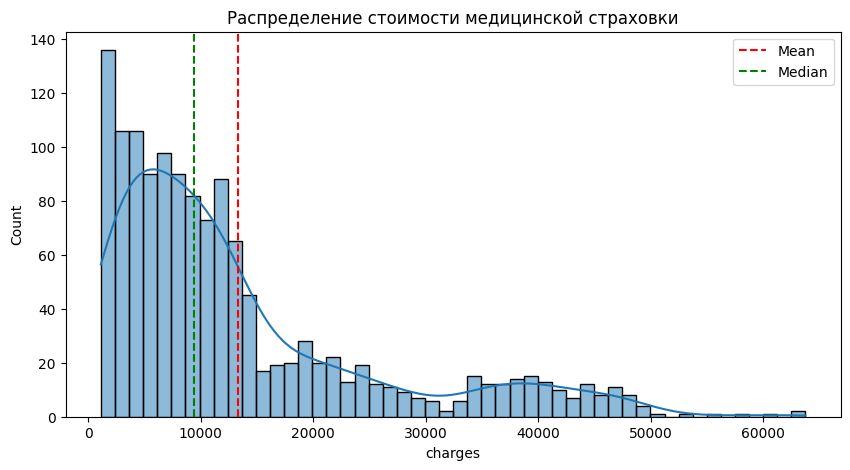

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='charges', kde=True, bins=50)
plt.axvline(df['charges'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['charges'].median(), color='green', linestyle='--', label='Median')
plt.title('Распределение стоимости медицинской страховки')
plt.legend()
plt.show()

# Двумерный анализ

## Числовые vs target 

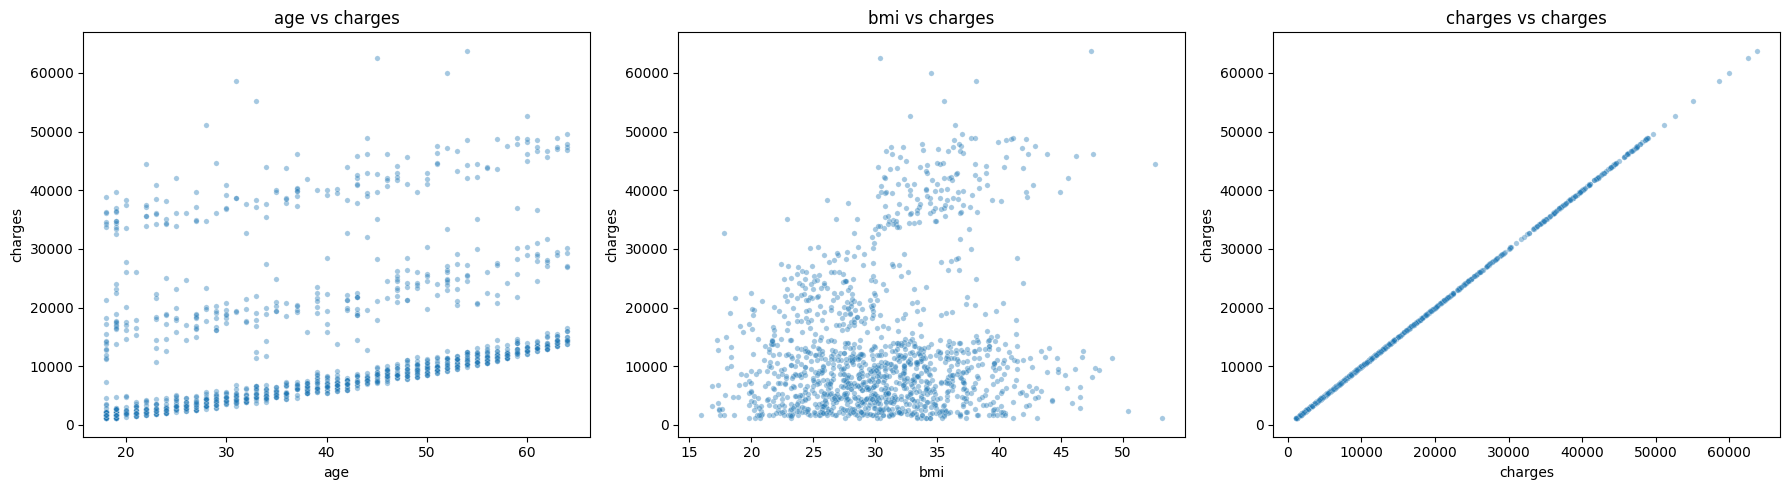

In [25]:
# Создаём сетку графиков
fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 5))

for i, col in enumerate(num_cols):
    # alpha=0.4 — прозрачность точек (чтобы видеть плотность)
    # s=15 — размер точек (по умолчанию крупные)
    sns.scatterplot(data=df, x=col, y='charges', alpha=0.4, s=15, ax=axes[i])
    axes[i].set_title(f'{col} vs charges')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('charges')

plt.tight_layout()
plt.show()

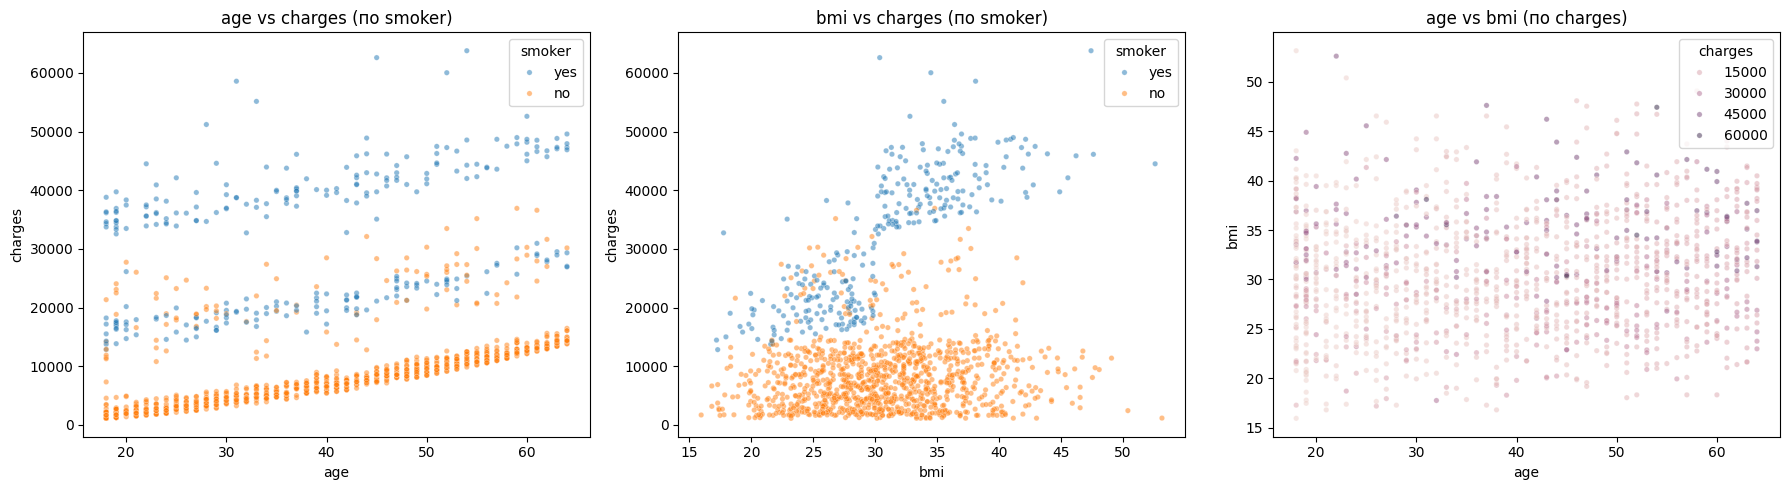

In [26]:
# Добавляем цвет по категориальному признаку — это уже 3D-анализ, но очень полезно
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# age vs charges, цвет по smoker
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.5, s=15, ax=axes[0])
axes[0].set_title('age vs charges (по smoker)')

# bmi vs charges, цвет по smoker
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.5, s=15, ax=axes[1])
axes[1].set_title('bmi vs charges (по smoker)')

# age vs bmi, цвет по charges
sns.scatterplot(data=df, x='age', y='bmi', hue='charges', alpha=0.5, s=15, ax=axes[2])
axes[2].set_title('age vs bmi (по charges)')

plt.tight_layout()
plt.show()

In [27]:
# Корреляция Пирсона (линейная связь)
numeric_cols = ['age', 'bmi', 'children', 'charges']
corr_pearson = df[numeric_cols].corr(method='pearson')['charges'].sort_values(ascending=False)
print("=== Корреляция Пирсона ===")
print(corr_pearson)

=== Корреляция Пирсона ===
charges     1.000000
age         0.299008
bmi         0.198341
children    0.067998
Name: charges, dtype: float64


In [28]:
# Корреляция Спирмена (монотонная, устойчива к выбросам)
corr_spearman = df[numeric_cols].corr(method='spearman')['charges'].sort_values(ascending=False)
print("\n=== Корреляция Спирмена ===")
print(corr_spearman)


=== Корреляция Спирмена ===
charges     1.000000
age         0.534392
children    0.133339
bmi         0.119396
Name: charges, dtype: float64


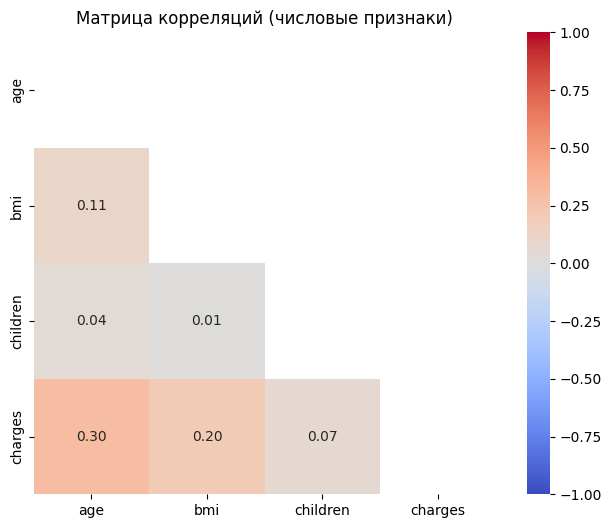

In [29]:
plt.figure(figsize=(8, 6))

# Маска для верхнего треугольника (чтобы не дублировать информацию)
mask = np.triu(np.ones_like(df[numeric_cols].corr(), dtype=bool))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,          # показывать числа
    fmt='.2f',           # 2 знака после запятой
    cmap='coolwarm',     # красный = положительная, синий = отрицательная
    center=0,            # белый цвет = 0
    mask=mask,           # скрыть верхний треугольник
    square=True,
    vmin=-1, vmax=1
)
plt.title('Матрица корреляций (числовые признаки)')
plt.show()

## Категориальное vs target

In [30]:
# Для каждой категориальной колонки смотрим среднее, медиану, std charges
for col in ['sex', 'smoker', 'region', 'children']:
    print(f"\n{'='*50}")
    print(f"Признак: {col}")
    print('='*50)
    
    stats = df.groupby(col)['charges'].agg(
        count='count',
        mean='mean',
        median='median',
        std='std',
        min='min',
        max='max'
    ).round(2)
    
    print(stats)


Признак: sex
        count      mean   median       std      min       max
sex                                                          
female    662  12569.58  9412.96  11128.70  1607.51  63770.43
male      676  13956.75  9369.62  12971.03  1121.87  62592.87

Признак: smoker
        count      mean    median       std       min       max
smoker                                                         
no       1064   8434.27   7345.41   5993.78   1121.87  36910.61
yes       274  32050.23  34456.35  11541.55  12829.46  63770.43

Признак: region
           count      mean    median       std      min       max
region                                                           
northeast    324  13406.38  10057.65  11255.80  1694.80  58571.07
northwest    325  12417.58   8965.80  11072.28  1621.34  60021.40
southeast    364  14735.41   9294.13  13971.10  1121.87  63770.43
southwest    325  12346.94   8798.59  11557.18  1241.56  52590.83

Признак: children
          count      mean    medi

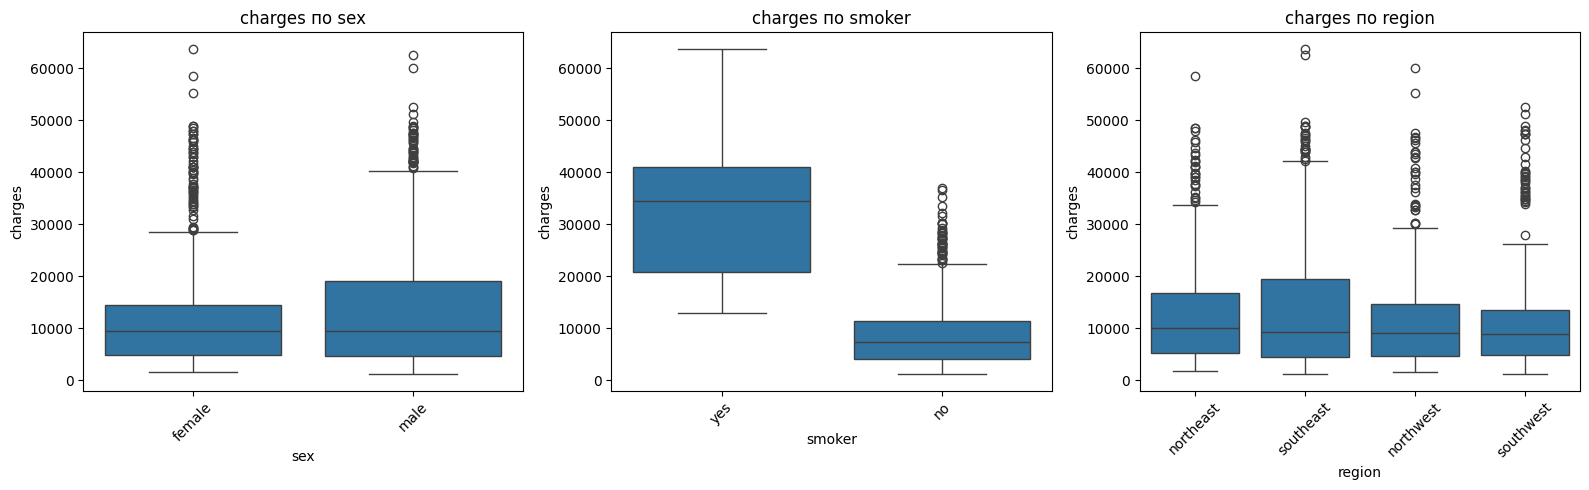

In [31]:
cat_features = ['sex', 'smoker', 'region']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(cat_features):
    # order — сортируем категории по медиане (для наглядности)
    order = df.groupby(col)['charges'].median().sort_values(ascending=False).index
    
    sns.boxplot(data=df, x=col, y='charges', order=order, ax=axes[i])
    axes[i].set_title(f'charges по {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [32]:
def correlation_ratio(categories, measurements):
    """
    η (eta) — корреляционное отношение.
    Интерпретация как у корреляции: 0 = нет связи, 1 = идеальная.
    """
    # 1. Превращаем категории в числа (0, 1, 2, ...)
    fcat, _ = pd.factorize(categories)
    cat_num = np.max(fcat) + 1
    
    # 2. Считаем средние и размеры по каждой группе
    y_avg_array = np.zeros(cat_num)
    n_array = np.zeros(cat_num)
    
    for i in range(cat_num):
        cat_measures = measurements.iloc[np.argwhere(fcat == i).flatten()]
        n_array[i] = len(cat_measures)
        y_avg_array[i] = np.average(cat_measures)
    
    # 3. Общее среднее
    y_total_avg = np.sum(np.multiply(y_avg_array, n_array)) / np.sum(n_array)
    
    # 4. Формула η
    numerator = np.sum(np.multiply(n_array, (y_avg_array - y_total_avg) ** 2))
    denominator = np.sum((measurements - y_total_avg) ** 2)
    
    if numerator == 0:
        return 0
    return np.sqrt(numerator / denominator)


# Считаем для всех категориальных
eta_scores = {}
for col in ['sex', 'smoker', 'region', 'children']:
    eta_scores[col] = correlation_ratio(df[col], df['charges'])

eta_series = pd.Series(eta_scores).sort_values(ascending=False)
print("=== Correlation Ratio (η) с charges ===")
print(eta_series.round(4))

=== Correlation Ratio (η) с charges ===
smoker      0.7873
children    0.1106
region      0.0814
sex         0.0573
dtype: float64


In [33]:
from scipy.stats import ttest_ind, f_oneway

# Для бинарных признаков (2 группы) — t-test
print("=== t-test (для бинарных признаков) ===")
for col in ['sex', 'smoker']:
    groups = [g['charges'].values for _, g in df.groupby(col)]
    stat, p = ttest_ind(*groups)
    sig = "✓ значим" if p < 0.05 else "✗ не значим"
    print(f"{col}: t={stat:.2f}, p-value={p:.6f} {sig}")

# Для многоклассовых (> 2 групп) — ANOVA
print("\n=== ANOVA (для многоклассовых признаков) ===")
for col in ['region', 'children']:
    groups = [g['charges'].values for _, g in df.groupby(col)]
    stat, p = f_oneway(*groups)
    sig = "✓ значим" if p < 0.05 else "✗ не значим"
    print(f"{col}: F={stat:.2f}, p-value={p:.6f} {sig}")

=== t-test (для бинарных признаков) ===
sex: t=-2.10, p-value=0.036133 ✓ значим
smoker: t=-46.66, p-value=0.000000 ✓ значим

=== ANOVA (для многоклассовых признаков) ===
region: F=2.97, p-value=0.030893 ✓ значим
children: F=3.30, p-value=0.005786 ✓ значим


## Анализ взаимодействия

sex      female      male
smoker                   
no       8762.3   8087.20
yes     30679.0  33042.01


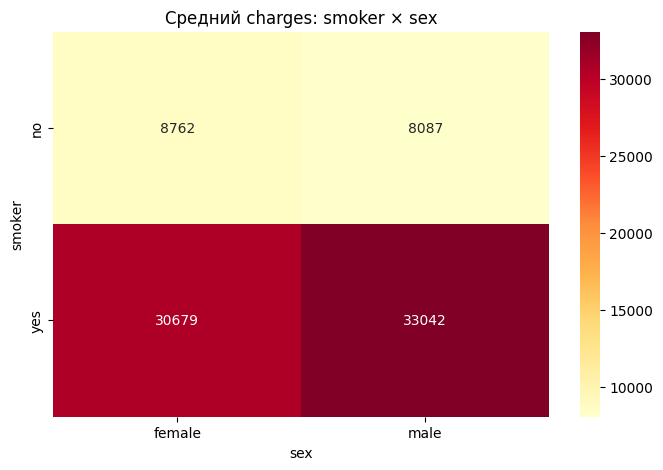

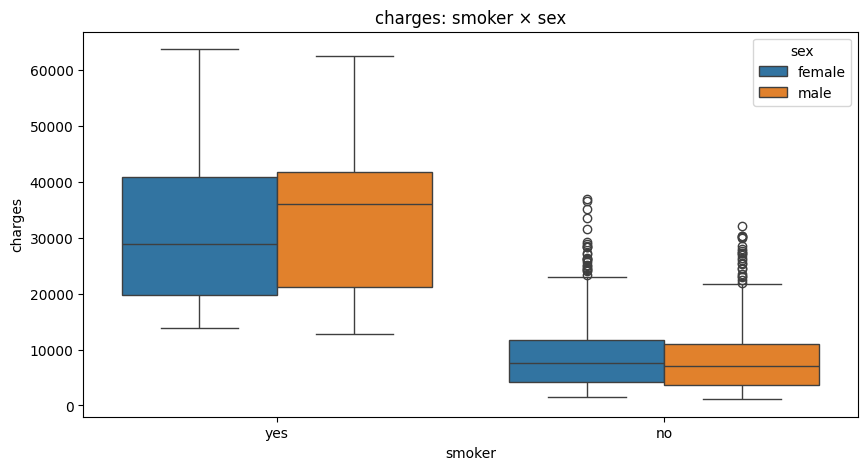

In [34]:
# Pivot table: средний charges по smoker × sex
pivot = df.pivot_table(
    values='charges',
    index='smoker',
    columns='sex',
    aggfunc='mean'
).round(2)

print(pivot)

# Визуализация
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Средний charges: smoker × sex')
plt.show()

# Также можно boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='smoker', y='charges', hue='sex')
plt.title('charges: smoker × sex')
plt.show()

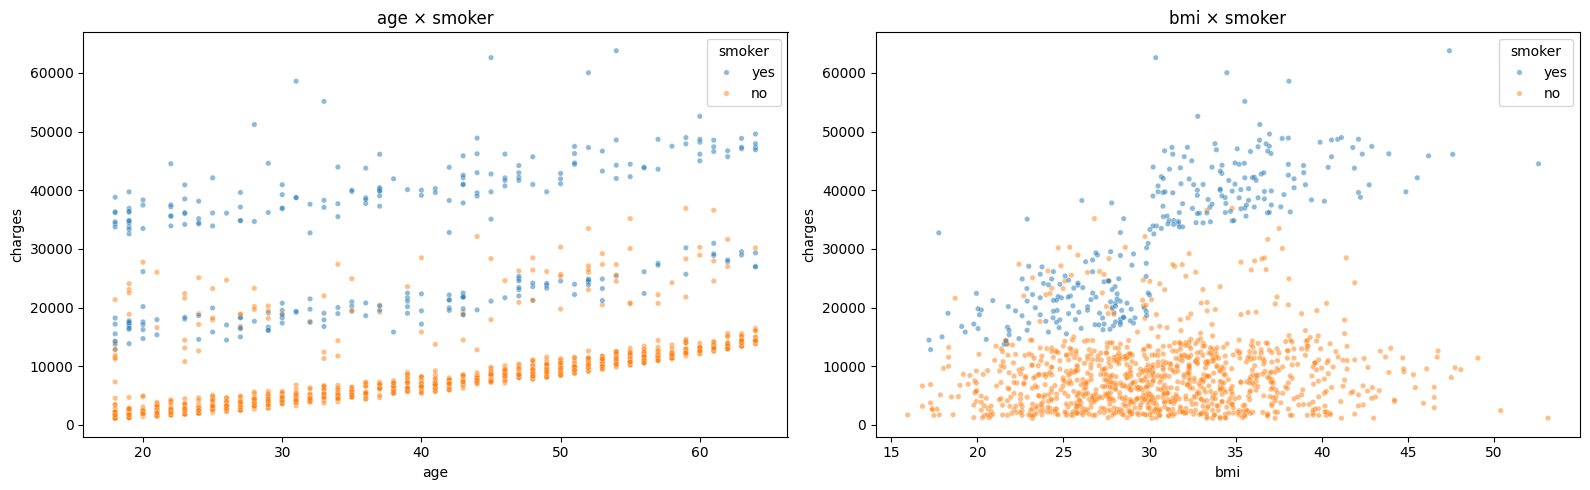


=== smoker = yes ===
age        0.368
bmi        0.806
charges    1.000
Name: charges, dtype: float64

=== smoker = no ===
age        0.628
bmi        0.084
charges    1.000
Name: charges, dtype: float64


In [35]:
# Scatterplot с hue — лучший способ
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# age vs charges, цвет по smoker
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.5, s=15, ax=axes[0])
axes[0].set_title('age × smoker')

# bmi vs charges, цвет по smoker
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.5, s=15, ax=axes[1])
axes[1].set_title('bmi × smoker')

plt.tight_layout()
plt.show()

# Количественно: корреляция age-charges отдельно для курящих и некурящих
for group in df['smoker'].unique():
    subset = df[df['smoker'] == group]
    corr = subset[['age', 'bmi', 'charges']].corr()['charges']
    print(f"\n=== smoker = {group} ===")
    print(corr.round(3))

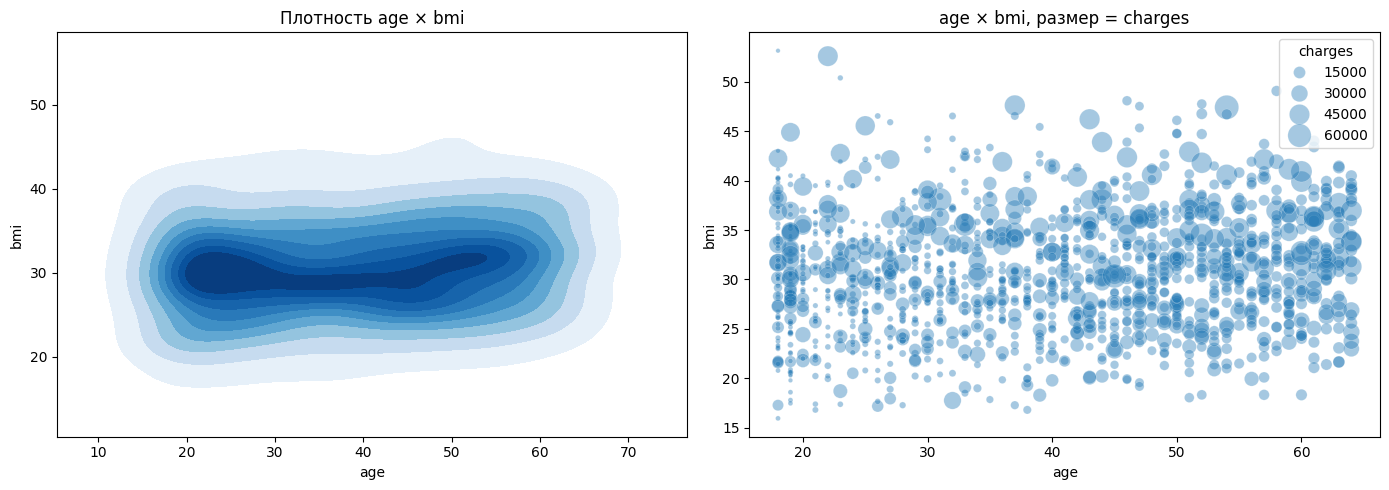

In [36]:
# 2D KDE plot — плотность точек в двумерном пространстве
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=df, x='age', y='bmi', fill=True, cmap='Blues', ax=axes[0])
axes[0].set_title('Плотность age × bmi')

# Или scatter с размером точек по target
sns.scatterplot(data=df, x='age', y='bmi', size='charges', 
                sizes=(10, 300), alpha=0.4, ax=axes[1])
axes[1].set_title('age × bmi, размер = charges')

plt.tight_layout()
plt.show()

## Топ признаков

=== Топ признаков по важности ===
smoker      0.7873
age         0.5344
children    0.1333
bmi         0.1194
region      0.0814
sex         0.0573
dtype: float64


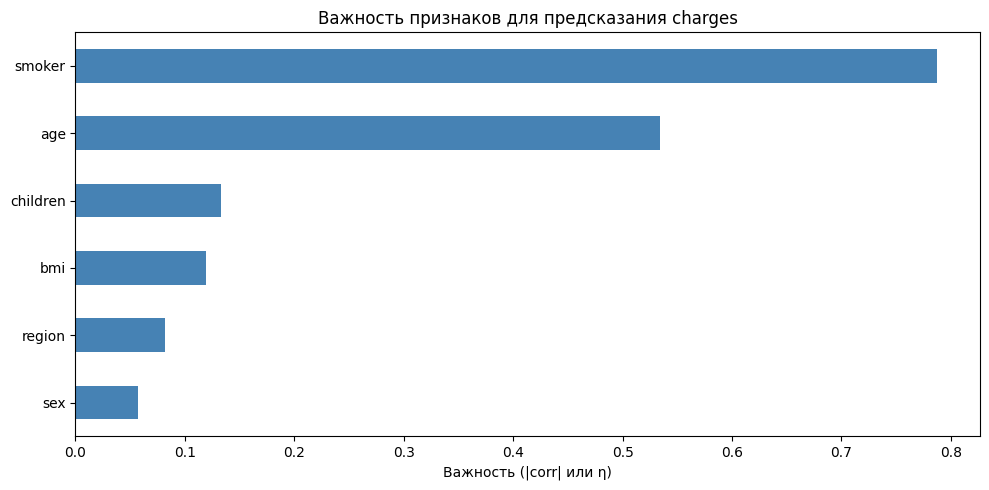

In [38]:
# 1. Числовые признаки — корреляция Спирмена с charges
numeric_importance = df[['age', 'bmi', 'children']].corrwith(
    df['charges'], method='spearman'
).abs()

# 2. Категориальные — correlation ratio
cat_importance = pd.Series({
    col: correlation_ratio(df[col], df['charges'])
    for col in ['sex', 'smoker', 'region']
})

# 3. Объединяем
all_importance = pd.concat([numeric_importance, cat_importance])
all_importance = all_importance.sort_values(ascending=False)

print("=== Топ признаков по важности ===")
print(all_importance.round(4))

# 4. Визуализируем
plt.figure(figsize=(10, 5))
all_importance.plot(kind='barh', color='steelblue')
plt.xlabel('Важность (|corr| или η)')
plt.title('Важность признаков для предсказания charges')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()